In [1]:
import time

import matplotlib.pyplot as plt

from motion_planning.database import Database
from motion_planning.database.db_annotator import populate_db
from motion_planning.experiments.utils.mp_sampler import MPSampler
from motion_planning.obstacle_sets import BiasedPassage
from motion_planning.search import Lightning
from motion_planning.space import PointRobot

pygame 2.6.1 (SDL 2.28.4, Python 3.12.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


# Setup Base Robot & Environment

In [2]:
env = PointRobot()
env.set_obstacles(BiasedPassage(bias=0.5, num_walls=3))

# Generate Path Database

In [3]:
db = Database()
mp_sampler = MPSampler(env, BiasedPassage, {"num_walls": 3, "bias": 0.5})

db_save_path = "../saves/lightning_example_database.pickle"
populate_db(db, mp_sampler, num_envs=2, num_tasks_per_env=20)
db.save_to_path(db_save_path)

Connecting Edges Using knn strategy
Env 1, Task 1
Num Times Extended: 0
Env 1, Task 2
Num Times Extended: 0
Env 1, Task 3
Num Times Extended: 0
Env 1, Task 4
Num Times Extended: 0
Env 1, Task 5
Num Times Extended: 0
Env 1, Task 6
Num Times Extended: 0
Env 1, Task 7
Num Times Extended: 0
Env 1, Task 8
Num Times Extended: 0
Env 1, Task 9
Num Times Extended: 0
Env 1, Task 10
Num Times Extended: 0
Env 1, Task 11
Num Times Extended: 0
Env 1, Task 12
Num Times Extended: 0
Env 1, Task 13
Num Times Extended: 0
Env 1, Task 14
Num Times Extended: 0
Env 1, Task 15
Num Times Extended: 0
Env 1, Task 16
Num Times Extended: 0
Env 1, Task 17
Num Times Extended: 0
Env 1, Task 18
Num Times Extended: 0
Env 1, Task 19
Num Times Extended: 0
Env 1, Task 20
Num Times Extended: 0
DB Size: 20
Connecting Edges Using knn strategy
Env 2, Task 1
Adding Nodes, Current Size: 861
Connecting Edges Using knn strategy
Num Times Extended: 1
Env 2, Task 2
Num Times Extended: 0
Env 2, Task 3
Num Times Extended: 0
Env 2, Ta

# Initialize Lightning

In [4]:
lightning = Lightning(env, db_save_path)

# Create Task to Solve

In [6]:
start, target = env.sample_task()

# Compute Path for Guidance for Given Task

In [7]:
start_time = time.time()
path = lightning.search(start, target)
end_time = time.time()
print(f"Time to search: {end_time - start_time}", len(path))

Time to compute Candidate Paths: 6.293697834014893
Search Time: 0.02025294303894043, Collision Checks: 98620
Search Time: 13.141836643218994, Collision Checks: 110933
Time to repair path: 13.240658044815063
Lightning Total Search Time: 19.535157918930054
Time to search: 19.535356044769287 171


# Draw Search Tree

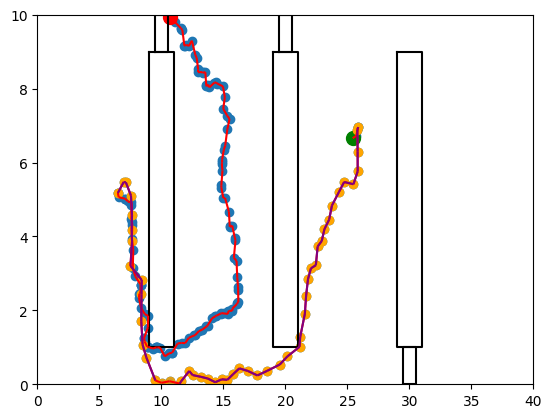

In [8]:
lightning.draw(plt.gca(), path, show_unrepaired_path=True, verbose=True)
plt.show()